In [1]:
import logging

import fastf1 as ff1
import fastf1.plotting
import matplotlib.pyplot as plt
import pandas as pd
from fastf1.core import Laps
from timple.timedelta import strftimedelta

%matplotlib widget
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme=None)
ff1.logger.set_log_level(logging.ERROR)

In [2]:
session = ff1.get_session(2025, 23, "Q")
session.load()

In [3]:
drivers = pd.unique(session.laps["Driver"])
drivers

array(['PIA', 'NOR', 'VER', 'RUS', 'ANT', 'HAD', 'SAI', 'ALO', 'GAS',
       'LEC', 'HUL', 'LAW', 'BEA', 'BOR', 'ALB', 'TSU', 'OCO', 'HAM',
       'STR', 'COL'], dtype=object)

In [4]:
fastest_laps = list()

for driver in drivers:
    driver_fastest_lap = session.laps.pick_drivers(driver).pick_fastest()
    fastest_laps.append(driver_fastest_lap)

fastest_laps = Laps(fastest_laps).sort_values(by="LapTime").reset_index(drop=True)

In [5]:
pole_lap = fastest_laps.pick_fastest()
fastest_laps["LapTimeDelta"] = fastest_laps["LapTime"] - pole_lap["LapTime"]
fastest_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeDelta
0,0 days 01:17:14.614000,PIA,81,0 days 00:01:19.387000,17.0,6.0,NaT,NaT,0 days 00:00:29.209000,0 days 00:00:26.919000,...,McLaren,0 days 01:15:55.227000,2025-11-29 19:04:18.924,1,NaN,False,,False,True,0 days 00:00:00
1,0 days 01:03:38.821000,NOR,4,0 days 00:01:19.495000,14.0,5.0,NaT,NaT,0 days 00:00:29.212000,0 days 00:00:26.978000,...,McLaren,0 days 01:02:19.326000,2025-11-29 18:50:43.023,1,NaN,False,,False,True,0 days 00:00:00.108000
2,0 days 01:17:29.505000,VER,1,0 days 00:01:19.651000,22.0,5.0,NaT,NaT,0 days 00:00:29.160000,0 days 00:00:27.064000,...,Red Bull Racing,0 days 01:16:09.854000,2025-11-29 19:04:33.551,1,NaN,False,,False,True,0 days 00:00:00.264000
3,0 days 01:18:14.205000,RUS,63,0 days 00:01:19.662000,25.0,5.0,NaT,NaT,0 days 00:00:29.246000,0 days 00:00:26.987000,...,Mercedes,0 days 01:16:54.543000,2025-11-29 19:05:18.240,1,NaN,False,,False,True,0 days 00:00:00.275000
4,0 days 01:17:42.763000,ANT,12,0 days 00:01:19.846000,21.0,6.0,NaT,NaT,0 days 00:00:29.331000,0 days 00:00:26.954000,...,Mercedes,0 days 01:16:22.917000,2025-11-29 19:04:46.614,1,NaN,False,,False,True,0 days 00:00:00.459000
5,0 days 01:03:58.015000,HAD,6,0 days 00:01:20.114000,17.0,6.0,NaT,NaT,0 days 00:00:29.473000,0 days 00:00:27.125000,...,Racing Bulls,0 days 01:02:37.901000,2025-11-29 18:51:01.598,1,NaN,False,,False,True,0 days 00:00:00.727000
6,0 days 00:52:24.211000,ALO,14,0 days 00:01:20.219000,14.0,4.0,NaT,NaT,0 days 00:00:29.500000,0 days 00:00:27.170000,...,Aston Martin,0 days 00:51:03.992000,2025-11-29 18:39:27.689,1,NaN,False,,False,True,0 days 00:00:00.832000
7,0 days 00:44:52,SAI,55,0 days 00:01:20.251000,15.0,4.0,NaT,NaT,0 days 00:00:29.546000,0 days 00:00:27.164000,...,Williams,0 days 00:43:31.749000,2025-11-29 18:31:55.446,1,NaN,False,,False,True,0 days 00:00:00.864000
8,0 days 00:52:39.077000,GAS,10,0 days 00:01:20.324000,14.0,5.0,NaT,NaT,0 days 00:00:29.495000,0 days 00:00:27.210000,...,Alpine,0 days 00:51:18.753000,2025-11-29 18:39:42.450,1,NaN,False,,False,True,0 days 00:00:00.937000
9,0 days 00:53:07.808000,LEC,16,0 days 00:01:20.343000,17.0,6.0,NaT,NaT,0 days 00:00:29.520000,0 days 00:00:27.318000,...,Ferrari,0 days 00:51:47.465000,2025-11-29 18:40:11.162,1,NaN,False,,False,True,0 days 00:00:00.956000


In [6]:
team_colors = list()

for _, lap in fastest_laps.iterlaps():
    color = ff1.plotting.get_team_color(lap["Team"], session=session)
    team_colors.append(color)

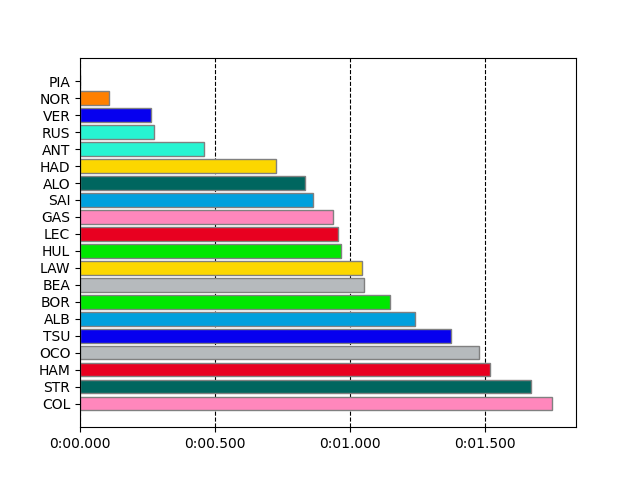

In [7]:
fig, ax = plt.subplots()
ax.barh(fastest_laps.index, fastest_laps['LapTimeDelta'],
        color=team_colors, edgecolor='grey')
ax.set_yticks(fastest_laps.index)
ax.set_yticklabels(fastest_laps["Driver"])

ax.invert_yaxis()

ax.set_axisbelow(True)
ax.xaxis.grid(True, which="major", linestyle="--", color="black", zorder=-1000)

In [8]:
lap_time_string = strftimedelta(pole_lap["LapTime"], "%m:%s.%ms")

plt.suptitle(f"{session.event["EventName"]} {session.event.year} Qualifying\n"
            f"Fastest Lap: {lap_time_string} ({pole_lap["Driver"]})")

Text(0.5, 0.98, 'Qatar Grand Prix 2025 Qualifying\nFastest Lap: 01:19.387 (PIA)')

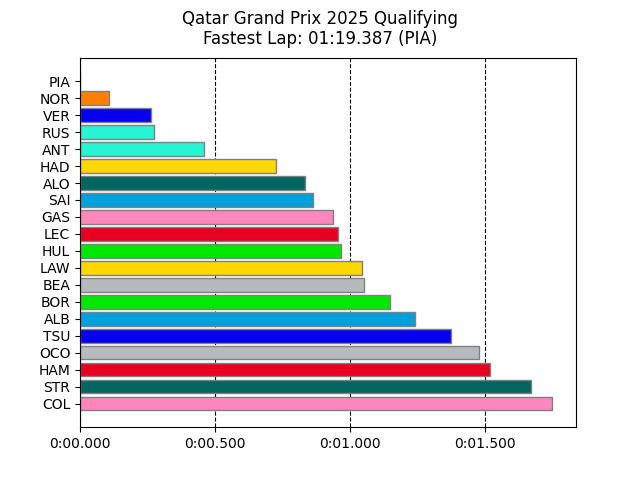

In [9]:
plt.show()